<a href="https://colab.research.google.com/github/guiby22/projet/blob/main/tp1_Modelisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import string, secrets, math

def entropy(key, charset_size):
    return len(key) * math.log2(charset_size)

charsets = {
    "ascii_lowercase": string.ascii_lowercase,
    "ascii_letters": string.ascii_letters,
    "digits": string.digits,
    "ascii_letters+digits+punctuation": string.ascii_letters + string.digits + string.punctuation
}

lengths = [8, 16, 32]

for name, charset in charsets.items():
    print(f"\n--- {name} ---")
    for L in lengths:
        key = ''.join(secrets.choice(charset) for _ in range(L))
        H = entropy(key, len(charset))
        print(f"Clé ({L} caractères): {key}")
        print(f"Entropie ≈ {H:.2f} bits")




--- ascii_lowercase ---
Clé (8 caractères): feyxevij
Entropie ≈ 37.60 bits
Clé (16 caractères): aqxcoeaywdlzmega
Entropie ≈ 75.21 bits
Clé (32 caractères): itrwbahpdjgwlpbmipvagdclatuvhjvy
Entropie ≈ 150.41 bits

--- ascii_letters ---
Clé (8 caractères): TzcjKbcj
Entropie ≈ 45.60 bits
Clé (16 caractères): AGVOtciHyeWAyVbF
Entropie ≈ 91.21 bits
Clé (32 caractères): fggGpYtAbBVLyCmbdriCoFUuzxGZXykl
Entropie ≈ 182.41 bits

--- digits ---
Clé (8 caractères): 18240503
Entropie ≈ 26.58 bits
Clé (16 caractères): 8365273275860349
Entropie ≈ 53.15 bits
Clé (32 caractères): 97296811668313599368265319950600
Entropie ≈ 106.30 bits

--- ascii_letters+digits+punctuation ---
Clé (8 caractères): /4@LWP@A
Entropie ≈ 52.44 bits
Clé (16 caractères): 63bUY3ytMt^?5s?d
Entropie ≈ 104.87 bits
Clé (32 caractères): qE2G<6Me}{ZI`2!]WY?k+8Va7DY+:g$v
Entropie ≈ 209.75 bits


In [ ]:
def caesar_cipher(message, shift):
    result = ""
    for char in message:
        if char.islower():
            result += chr((ord(char) - ord('a') + shift) % 26 + ord('a'))
        elif char.isupper():
            result += chr((ord(char) - ord('A') + shift) % 26 + ord('A'))
        elif char.isdigit():
            result += chr((ord(char) - ord('0') + shift) % 10 + ord('0'))
        else:
            result += char
    return result

def caesar_decipher(cipher, shift):
    return caesar_cipher(cipher, -shift)

# Exemple
msg = "Crypto2026"
shift = 5
cipher = caesar_cipher(msg, shift)
print("Message chiffré :", cipher)
print("Message déchiffré :", caesar_decipher(cipher, shift))

Message chiffré : Hwduyt7571
Message déchiffré : Crypto2026


In [ ]:
import string, secrets

def xor_cipher(message, key):
    return ''.join(chr(ord(m) ^ ord(k)) for m, k in zip(message, key))

# Génération de clé aléatoire
message = "Sécurité2026"
charset = string.printable
key = ''.join(secrets.choice(charset) for _ in range(len(message)))

cipher = xor_cipher(message, key)
decrypted = xor_cipher(cipher, key)

print("Message original :", message)
print("Clé :", key)
print("Message chiffré :", cipher)
print("Message déchiffré :", decrypted)

Message original : Sécurité2026
QU<v
Message chiffré : wÒ5O?:äce@
Message déchiffré : Sécurité2026


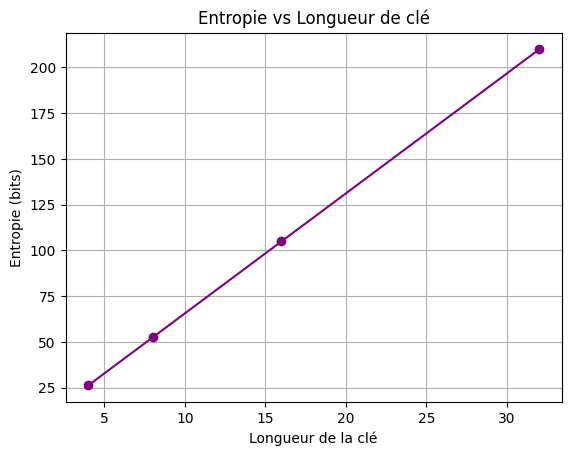

In [ ]:
import matplotlib.pyplot as plt

def entropy(length, charset_size):
    return length * math.log2(charset_size)

lengths = [4, 8, 16, 32]
charset_size = len(string.ascii_letters + string.digits + string.punctuation)
entropies = [entropy(L, charset_size) for L in lengths]

plt.plot(lengths, entropies, marker='o', color='purple')
plt.title("Entropie vs Longueur de clé")
plt.xlabel("Longueur de la clé")
plt.ylabel("Entropie (bits)")
plt.grid(True)
plt.show()